<a href="https://colab.research.google.com/github/25me01030-Dhruv/Computer_Vision_with_ResNet_on-CIFAR-10/blob/main/ResNet_18_on_CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

# Loading the CIFAR 10 dataset and applying data augmentation

In [2]:
# Apply normalization into pixels with mean 0.5 and SD 0.5.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),  # Apply normalization into pixels with mean 0.5 and SD 0.5.
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop([32,32])
])

In [3]:
# Download and load the training set

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

100%|██████████| 170M/170M [00:05<00:00, 31.2MB/s]


In [4]:
# Download and load the test set
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

In [5]:
print(f"{len(testset)} : Test images")
print(f"{len(trainset)} : Train images")

10000 : Test images
50000 : Train images


# Importing required libraries and checking for GPU

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as Fun

In [7]:
torch.manual_seed(42)

In [8]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# Building train and test batches through dataloader class

In [9]:
trainloader = DataLoader(trainset, batch_size=200, shuffle=True, num_workers=4)   # Building batches for the training set out of 50000 images
testloader = DataLoader(testset, batch_size=200, shuffle = False, num_workers=4)   # Building batches for the training set out of 10000 images

classes = ('plane', 'car', 'bird', 'cat','deer', 'dog', 'frog', 'horse', 'ship', 'truck')   # Got the names from the internet

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [10]:
for images,labels in trainloader :
 print(f'Images  : ', images.shape)
 print(f'Labels  : ', labels.shape)
 break

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Images  :  torch.Size([200, 3, 32, 32])
Labels  :  torch.Size([200])


# Visualising some sample images

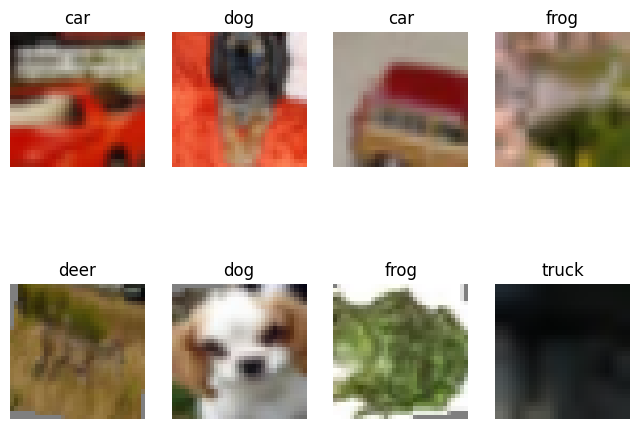

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import random

fig, axes = plt.subplots(2,4, figsize=(8,6))
axes = axes.ravel()

for i in range (len(axes)) :    # 8
  image_index = random.randint(0,len(trainset)-1)
  image, label = trainset[image_index]
  axes[i].imshow(image.permute(1, 2, 0).numpy() / 2 + 0.5)  # Convert image into numpy array of height : 1, width : 2, channel : 0 and then denormalize
  axes[i].set_title(classes[label])
  axes[i].axis('off')

plt.show()

In [12]:
len(axes)

8

# Residual block architecture

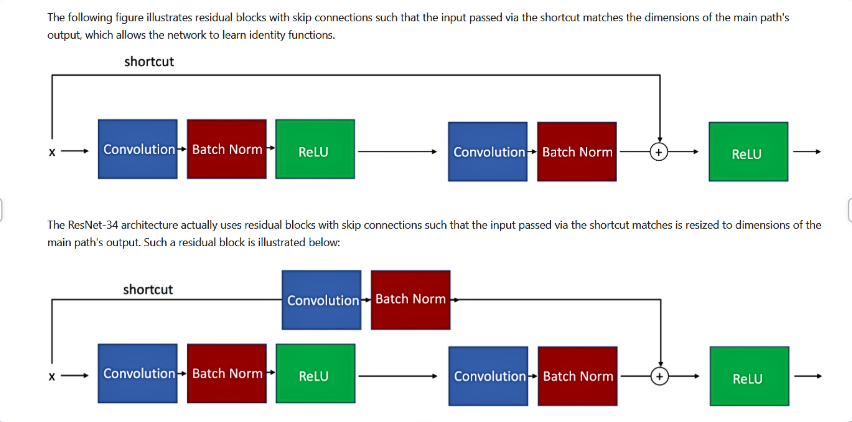

In [13]:
class ResidualBlock(nn.Module) :
  def __init__(self,in_channels, out_channels, stride = 1, downsample = None) :
     super(ResidualBlock,self).__init__()

     # First convolution layer
     self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size = 3, stride = stride, padding = 1, bias = False)
     self.bn1 = nn.BatchNorm2d(out_channels)
     self.relu = nn.ReLU()

     # 2nd convolution layer
     self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding = 1, stride = 1, bias = False)
     self.bn2 = nn.BatchNorm2d(out_channels)

     self.shortcut = nn.Sequential()  # dim of x and result are same

     if stride != 1 or in_channels != out_channels:   # dim of x and result are not same then apply convolution and batch_normalization to make them equal
          self.shortcut = nn.Sequential(
                  nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                  nn.BatchNorm2d(out_channels)
                  )

  def forward(self,x) :

       # First layer
       result = self.conv1(x)
       result = self.bn1(result)
       result = self.relu(result)

       # Second layer
       result = self.conv2(result)
       result = self.bn2(result)

       result += self.shortcut(x)
       result = self.relu(result)

       return result

# ResNet 18 architecture

In [18]:
class ResNet18 (nn.Module) :

  def __init__(self, n_class = 10) :
      super(ResNet18, self).__init__()

      self.in_channels = 64   # No of channels

      # Initial convolutional layer
      self.conv1 = nn.Conv2d(3, 64, kernel_size=5, stride=1, padding=1, bias=False)
      self.bn1 = nn.BatchNorm2d(64)
      self.relu = nn.ReLU(inplace=True)

      # 4 layers for residual block
      self.layer1 = self._make_layer(ResidualBlock, 64,  2,  stride = 1)
      self.layer2 = self._make_layer(ResidualBlock, 128, 2,  stride = 2)
      self.layer3 = self._make_layer(ResidualBlock, 256, 2,  stride = 2)
      self.layer4 = self._make_layer(ResidualBlock, 512, 2,  stride = 2)

      # Average pooling layer
      self.avgpool = nn.AdaptiveAvgPool2d((1,1))

      # Drop out layer
      self.dropout = nn.Dropout(p = 0.5)

      # ANN layer
      self.fully_connected = nn.Linear(512, n_class)

  def _make_layer(self, block, out_channels, num_blocks, stride):
    strides = [stride] + [1]*(num_blocks-1)
    layers = []
    for s in strides:
        layers.append(block(self.in_channels, out_channels, s))
        self.in_channels = out_channels
    return nn.Sequential(*layers)

  def forward(self, X) :
    result = self.conv1(X)
    result = self.bn1(result)
    result = self.relu(result)

    result = self.layer1(result)
    result = self.layer2(result)
    result = self.layer3(result)
    result = self.layer4(result)

    result = self.avgpool(result)
    result = self.dropout(result)
    result = result.view(result.size(0), -1)
    result = self.fully_connected(result)

    return result

model = ResNet18().to(device)
print(model)

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1

# Setting the hyperparameters

In [35]:
lr = 0.1
epochs = 10
lss_fn = nn.CrossEntropyLoss()

model.to(device)

optimizer = optim.SGD(model.parameters(), momentum=0.9, lr=lr, weight_decay=1e-4)

# Calculating accuracy for training set and test set

# Training pipeline calculating loss for each epoch

In [36]:
train_losses = []
train_acc_list = []
test_acc_list = []

for epoch in range(epochs):
    model.train()  # Set model to training mode
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for batch_images, batch_labels in trainloader:
        batch_images, batch_labels = batch_images.to(device), batch_labels.to(device)

        optimizer.zero_grad()
        output = model(batch_images)
        loss = lss_fn(output, batch_labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()  # Accumulate batch loss
        _, predicted = torch.max(output.data, 1)
        total_train += batch_labels.size(0)
        correct_train += (predicted == batch_labels).sum().item()

    avg_train_loss = train_loss / len(trainloader) # Average loss over all batches
    train_losses.append(avg_train_loss)
    train_accuracy = correct_train / total_train
    train_acc_list.append(train_accuracy * 100) # Store as percentage

    # Evaluate on the test set after each epoch
    model.eval()  # Set model to evaluation mode
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for batch_images, batch_labels in testloader:
            batch_images, batch_labels = batch_images.to(device), batch_labels.to(device)
            outputs = model(batch_images)
            _, predicted = torch.max(outputs.data, 1)
            total_test += batch_labels.size(0)
            correct_test += (predicted == batch_labels).sum().item()

    test_accuracy = correct_test / total_test
    test_acc_list.append(test_accuracy * 100) # Store as percentage

    print(f'Epoch [{epoch+1}/{epochs}], ')
    print(f' Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy*100:.4f}, Test Acc: {test_accuracy*100:.4f}')


Epoch [1/10], 
 Train Loss: 0.5891, Train Acc: 79.5100, Test Acc: 76.7400
Epoch [2/10], 
 Train Loss: 0.5838, Train Acc: 79.8860, Test Acc: 75.5200
Epoch [3/10], 
 Train Loss: 0.5871, Train Acc: 79.5340, Test Acc: 75.2700
Epoch [4/10], 
 Train Loss: 0.5776, Train Acc: 79.9980, Test Acc: 74.8700
Epoch [5/10], 
 Train Loss: 0.5778, Train Acc: 80.1120, Test Acc: 75.8000
Epoch [6/10], 
 Train Loss: 0.5711, Train Acc: 80.1860, Test Acc: 77.6000
Epoch [7/10], 
 Train Loss: 0.5792, Train Acc: 79.9400, Test Acc: 77.4800
Epoch [8/10], 
 Train Loss: 0.5626, Train Acc: 80.3820, Test Acc: 76.7600
Epoch [9/10], 
 Train Loss: 0.5656, Train Acc: 80.3680, Test Acc: 77.3600
Epoch [10/10], 
 Train Loss: 0.5547, Train Acc: 80.6800, Test Acc: 77.9500


# Visualising loss and accuracy vs epoch

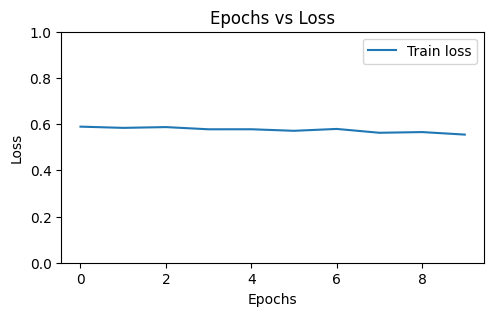

In [40]:
plt.figure(figsize=(12,3))
plt.subplot(1,2,1)
plt.plot(train_losses, label = 'Train loss')
plt.xlabel('Epochs')
# plt.xlim(0,20) # Removed fixed x-axis limit
plt.ylim(0,1) # Adjusted y-axis for better visibility
plt.ylabel('Loss')
plt.title('Epochs vs Loss')
plt.legend()
plt.show()

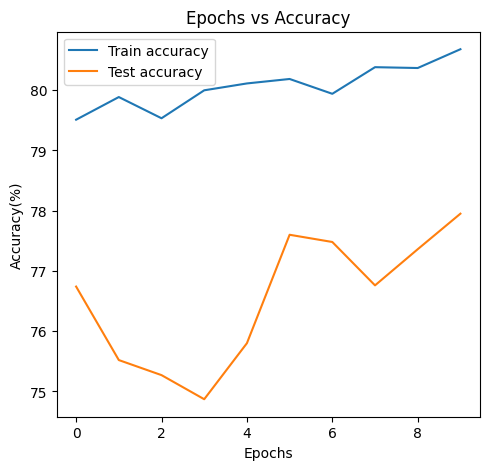

In [38]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
plt.plot(train_acc_list, label = 'Train accuracy')
plt.plot(test_acc_list, label = 'Test accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy(%)')
plt.title('Epochs vs Accuracy')
plt.legend()
plt.show()

# Final accuracy on train & test set

In [41]:
# Final evaluation on train data

total = 0
correct = 0

with torch.no_grad() :
  for epoch in range(epochs) :

   for batch_images, batch_labels in trainloader:
    batch_images, batch_labels = batch_images.to(device), batch_labels.to(device)

    output = model(batch_images)

    _, predicted = torch.max(output,1)
    total = total + batch_labels.shape[0]
    correct = correct + (predicted == batch_labels).sum().item()

train_accuracy = correct/total
print(f'Final accuracy : {train_accuracy*100} %')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bcf74784ae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == 

Final accuracy : 81.434 %


In [39]:
# Final evaluation on test data

total = 0
correct = 0

with torch.no_grad() :
  for epoch in range(epochs) :

   for batch_images, batch_labels in testloader:
    batch_images, batch_labels = batch_images.to(device), batch_labels.to(device)

    output = model(batch_images)

    _, predicted = torch.max(output,1)
    total = total + batch_labels.shape[0]
    correct = correct + (predicted == batch_labels).sum().item()

test_accuracy = correct/total
print(f'Final accuracy : {test_accuracy*100} %')

Final accuracy : 77.83099999999999 %
